# Exploratory Data Analysis - Heart Disease UCI Dataset

**Dataset**: Cleveland Heart Disease (processed) from UCI ML Repository  
**Records**: 303 patients, 14 attributes  
**Goal**: Binary classification — presence vs absence of heart disease

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys

# Setup
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# Add src to path
sys.path.insert(0, os.path.join(os.getcwd(), '..', 'src'))
from data_loader import load_cleveland_data

SAVE_DIR = os.path.join('..', 'screenshots', 'eda')
os.makedirs(SAVE_DIR, exist_ok=True)

# Fetch data directly from UCI Repository
df = load_cleveland_data()
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


## 1. Dataset Overview

In [2]:
print('=== Data Types ===')
print(df.dtypes)
print(f'\n=== Shape: {df.shape} ===')
print(f'\n=== Statistical Summary ===')
df.describe()

=== Data Types ===
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca          float64
thal        float64
num           int64
dtype: object

=== Shape: (303, 14) ===

=== Statistical Summary ===


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


In [3]:
print('=== Info ===')
df.info()

=== Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  num       303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB


## 2. Missing Value Analysis

      Missing Count  Missing %
ca                4   1.320132
thal              2   0.660066

Total missing values: 6 out of 4242 (0.14%)


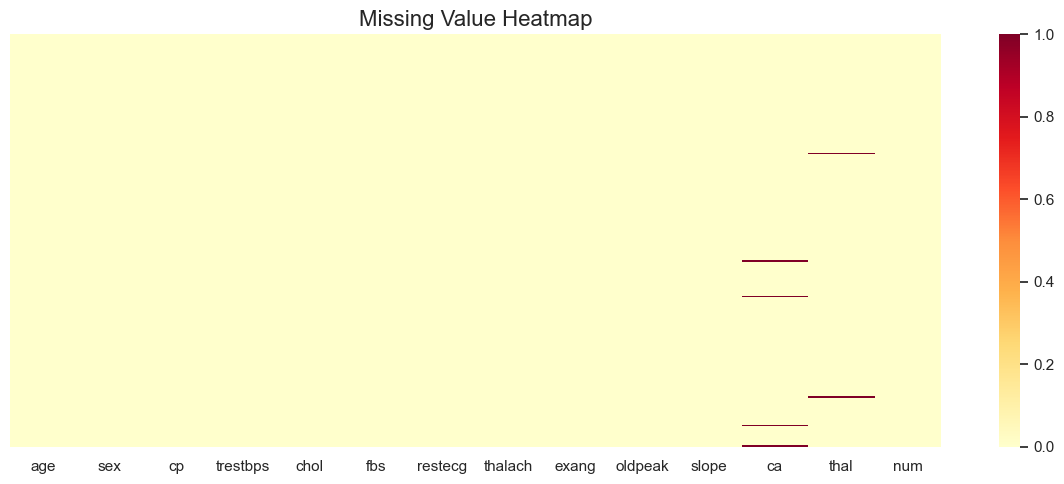

In [4]:
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])
print(f'\nTotal missing values: {df.isnull().sum().sum()} out of {df.shape[0] * df.shape[1]} ({df.isnull().sum().sum() / (df.shape[0] * df.shape[1]) * 100:.2f}%)')

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='YlOrRd', ax=ax)
ax.set_title('Missing Value Heatmap', fontsize=16)
fig.tight_layout()
fig.savefig(os.path.join(SAVE_DIR, 'missing_values_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

## 3. Target Variable Distribution

The `num` column indicates heart disease diagnosis:  
- 0 = no presence  
- 1-4 = presence (varying severity)  

We binarize: 0 → No Disease, 1-4 → Disease

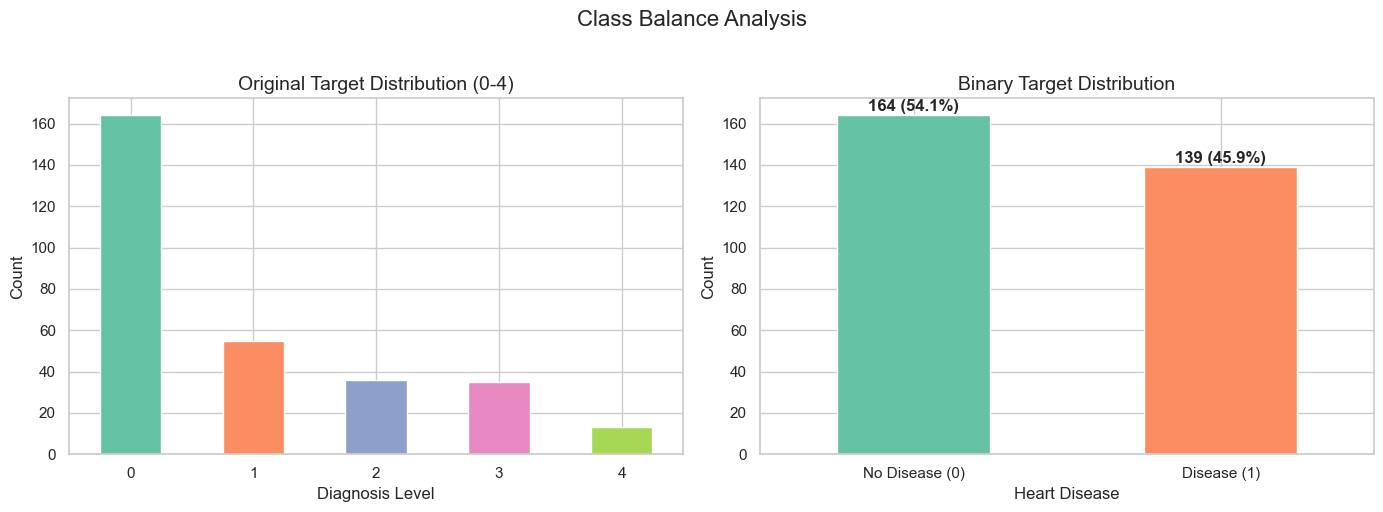

In [5]:
# Original multi-class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['num'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color=sns.color_palette('Set2'))
axes[0].set_title('Original Target Distribution (0-4)', fontsize=14)
axes[0].set_xlabel('Diagnosis Level')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Binary distribution
target_binary = (df['num'] > 0).astype(int)
counts = target_binary.value_counts().sort_index()
colors = ['#66c2a5', '#fc8d62']
counts.plot(kind='bar', ax=axes[1], color=colors)
axes[1].set_title('Binary Target Distribution', fontsize=14)
axes[1].set_xlabel('Heart Disease')
axes[1].set_ylabel('Count')
axes[1].set_xticklabels(['No Disease (0)', 'Disease (1)'], rotation=0)

for i, v in enumerate(counts):
    axes[1].text(i, v + 2, f'{v} ({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')

fig.suptitle('Class Balance Analysis', fontsize=16, y=1.02)
fig.tight_layout()
fig.savefig(os.path.join(SAVE_DIR, 'class_balance.png'), dpi=150, bbox_inches='tight')
plt.show()

## 4. Feature Distributions

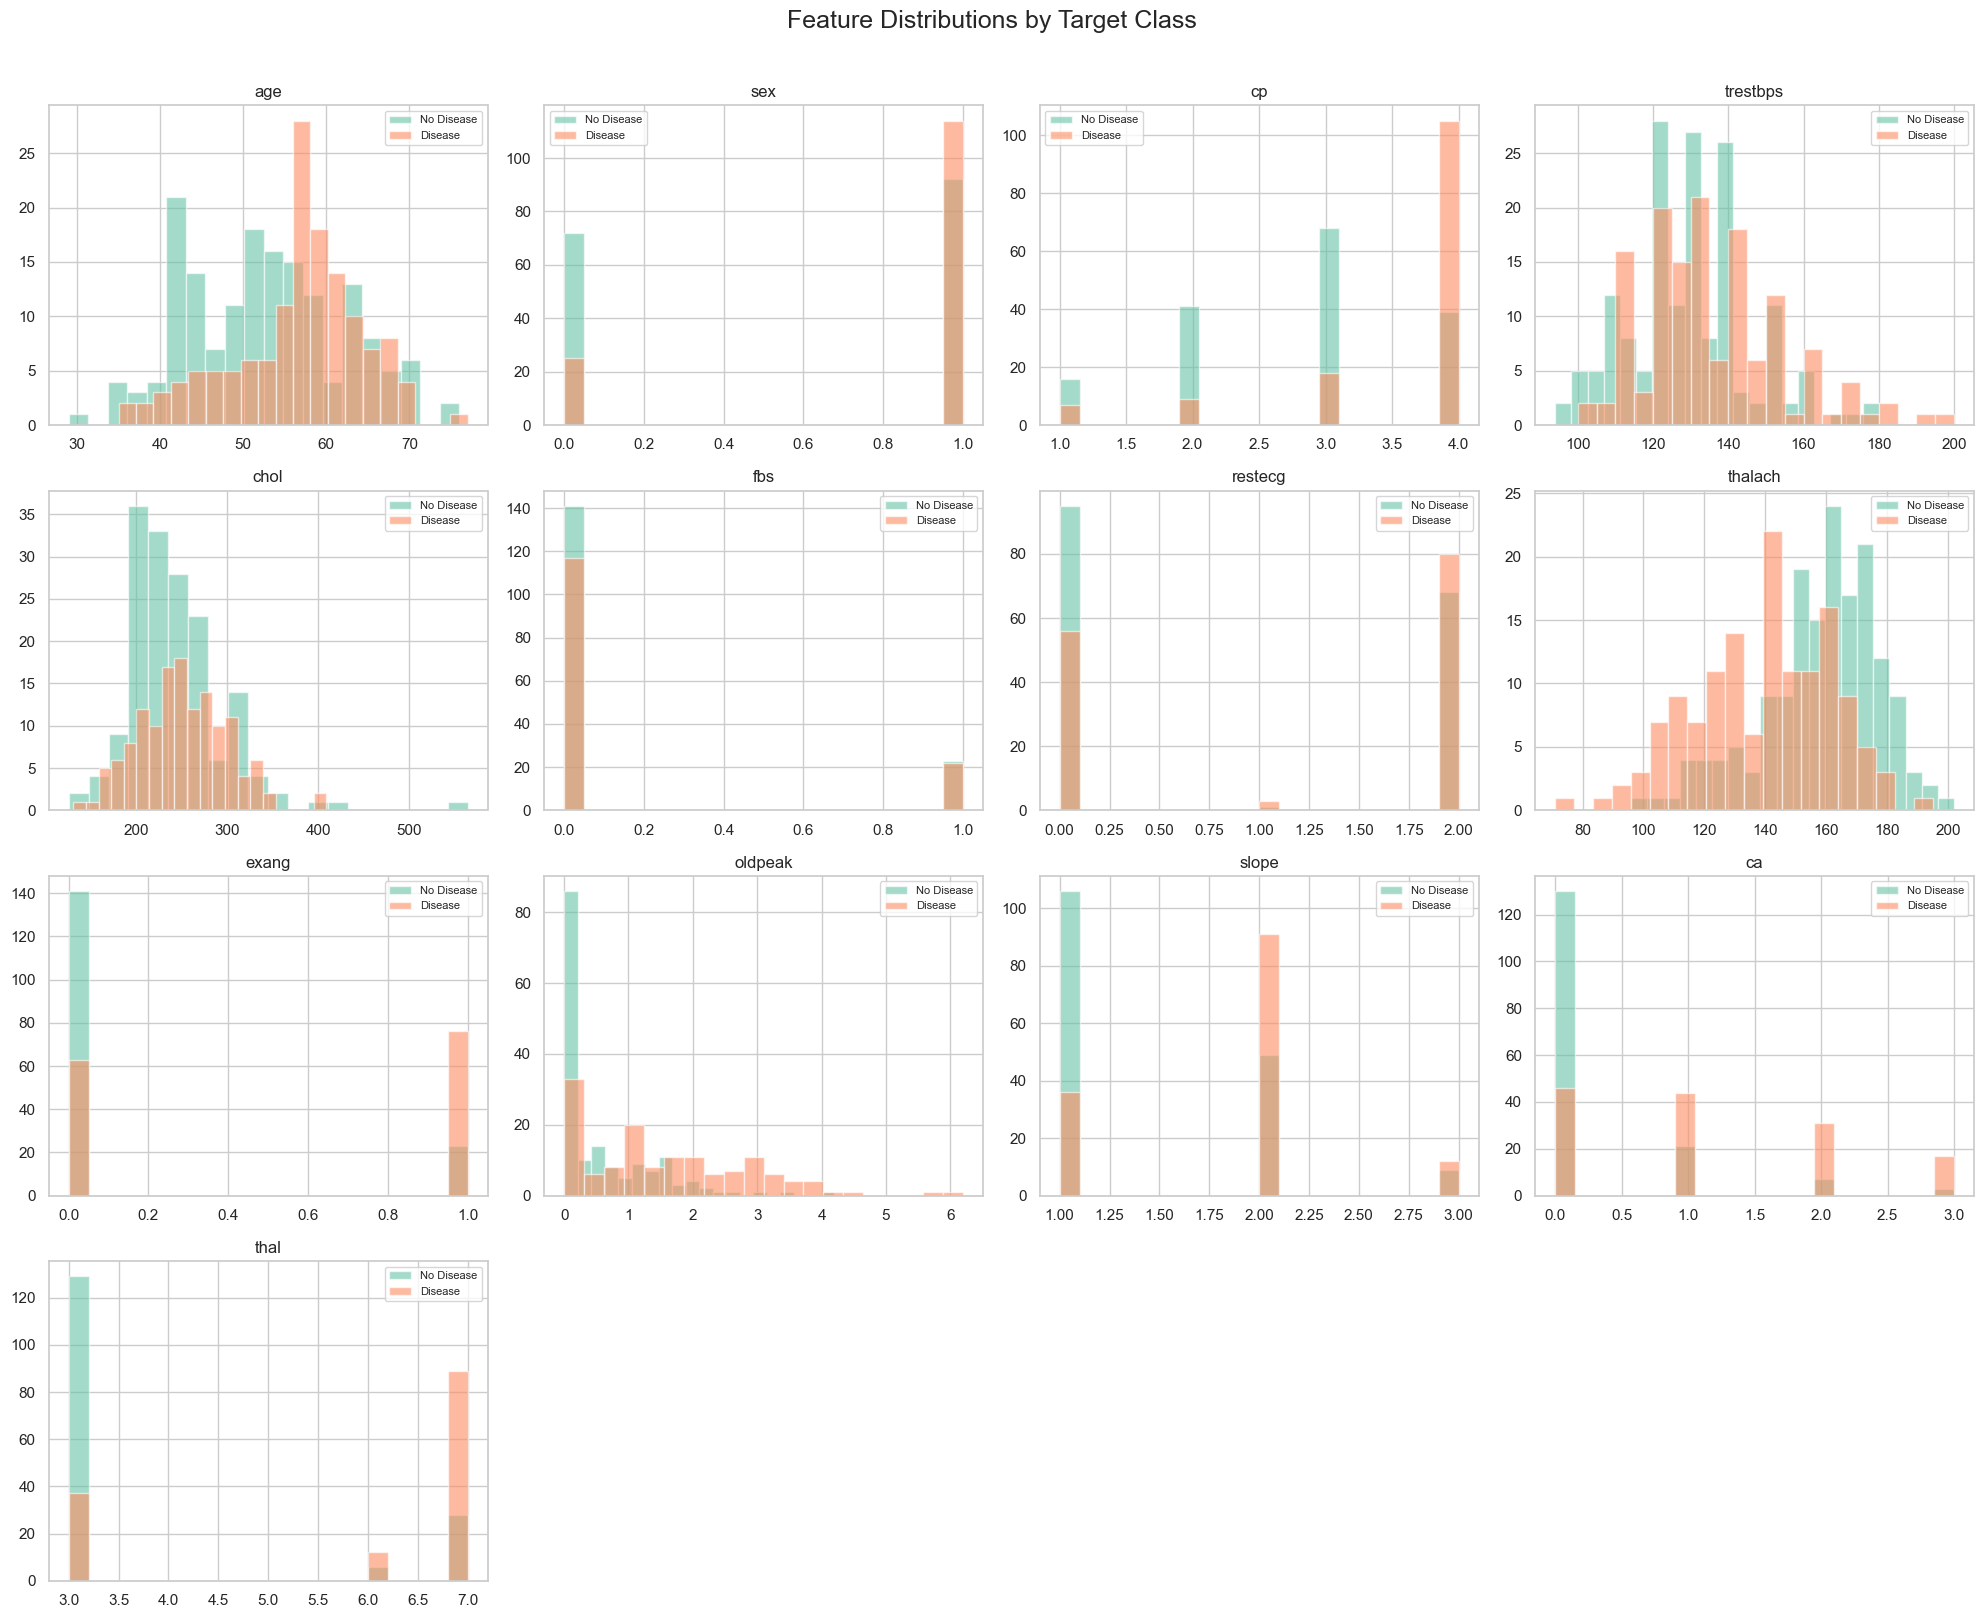

In [6]:
# Histograms for all 13 features
features = [c for c in df.columns if c != 'num']
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()

df['target'] = (df['num'] > 0).astype(int)

for i, col in enumerate(features):
    ax = axes[i]
    for label, color in zip([0, 1], ['#66c2a5', '#fc8d62']):
        subset = df[df['target'] == label][col].dropna()
        ax.hist(subset, bins=20, alpha=0.6, label=f'{"No Disease" if label==0 else "Disease"}', color=color)
    ax.set_title(col, fontsize=12)
    ax.legend(fontsize=8)

# Hide empty subplots
for j in range(len(features), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Feature Distributions by Target Class', fontsize=18, y=1.01)
fig.tight_layout()
fig.savefig(os.path.join(SAVE_DIR, 'feature_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()

df.drop(columns=['target'], inplace=True)

## 5. Correlation Heatmap

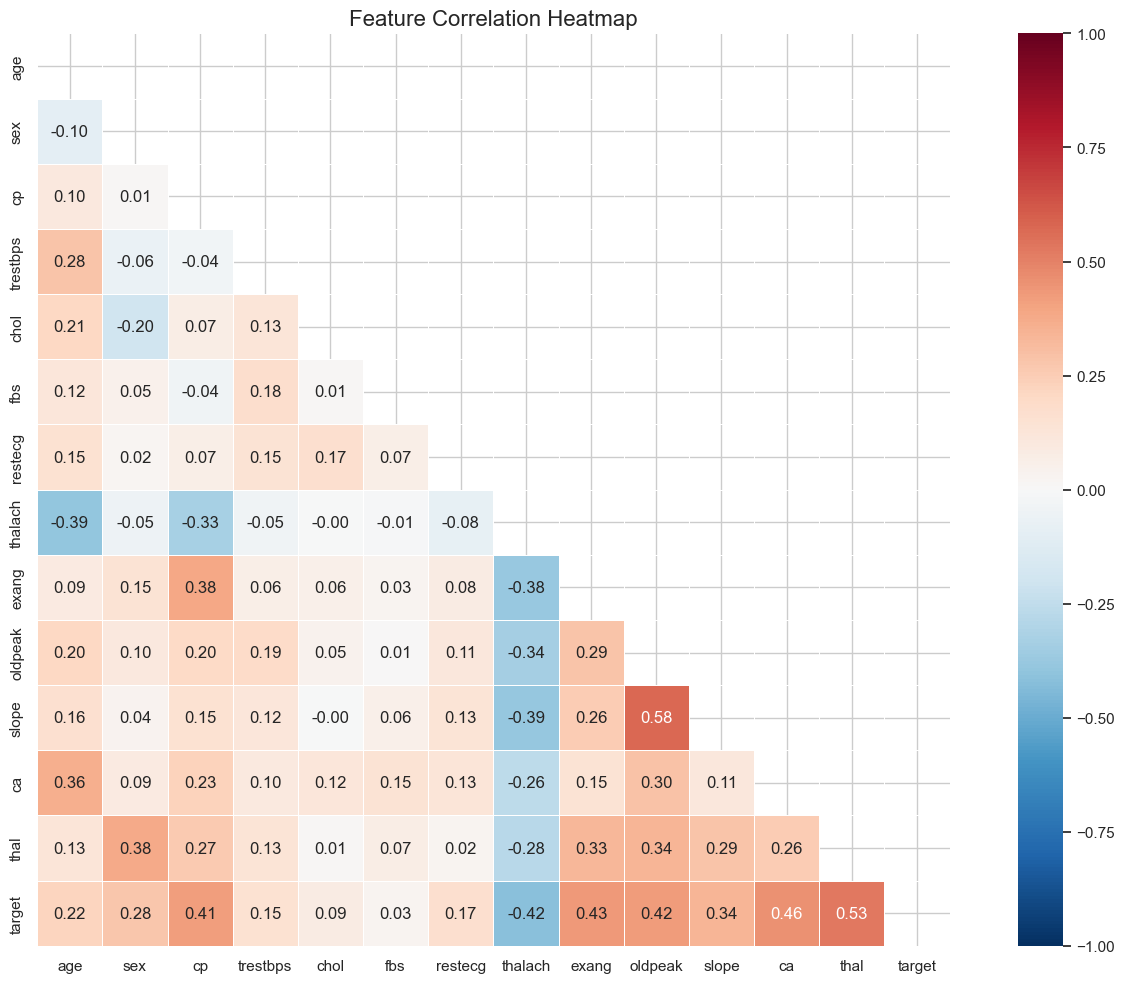

Top features correlated with target (absolute value):
thal        0.525689
ca          0.460442
exang       0.431894
oldpeak     0.424510
thalach     0.417167
cp          0.414446
slope       0.339213
sex         0.276816
age         0.223120
restecg     0.169202
trestbps    0.150825
chol        0.085164
fbs         0.025264
Name: target, dtype: float64


In [7]:
# Add binary target for correlation
df_corr = df.copy()
df_corr['target'] = (df_corr['num'] > 0).astype(int)
df_corr.drop(columns=['num'], inplace=True)

fig, ax = plt.subplots(figsize=(14, 10))
corr_matrix = df_corr.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Feature Correlation Heatmap', fontsize=16)
fig.tight_layout()
fig.savefig(os.path.join(SAVE_DIR, 'correlation_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

# Top correlations with target
target_corr = corr_matrix['target'].drop('target').abs().sort_values(ascending=False)
print('Top features correlated with target (absolute value):')
print(target_corr)

## 6. Box Plots by Target Class

/var/folders/0_/0j2bgqds4hgfp4qzk83rrd_w0000gn/T/ipykernel_12909/2471338376.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_box, x='target', y=col, ax=axes[i], palette=['#66c2a5', '#fc8d62'])
/var/folders/0_/0j2bgqds4hgfp4qzk83rrd_w0000gn/T/ipykernel_12909/2471338376.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['No Disease', 'Disease'])
/var/folders/0_/0j2bgqds4hgfp4qzk83rrd_w0000gn/T/ipykernel_12909/2471338376.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_box, x='target', y=col, ax=axes[i], palette=['#66c2a5', '#fc8d62'])
/var/folders/0_/0j2bgqds4h

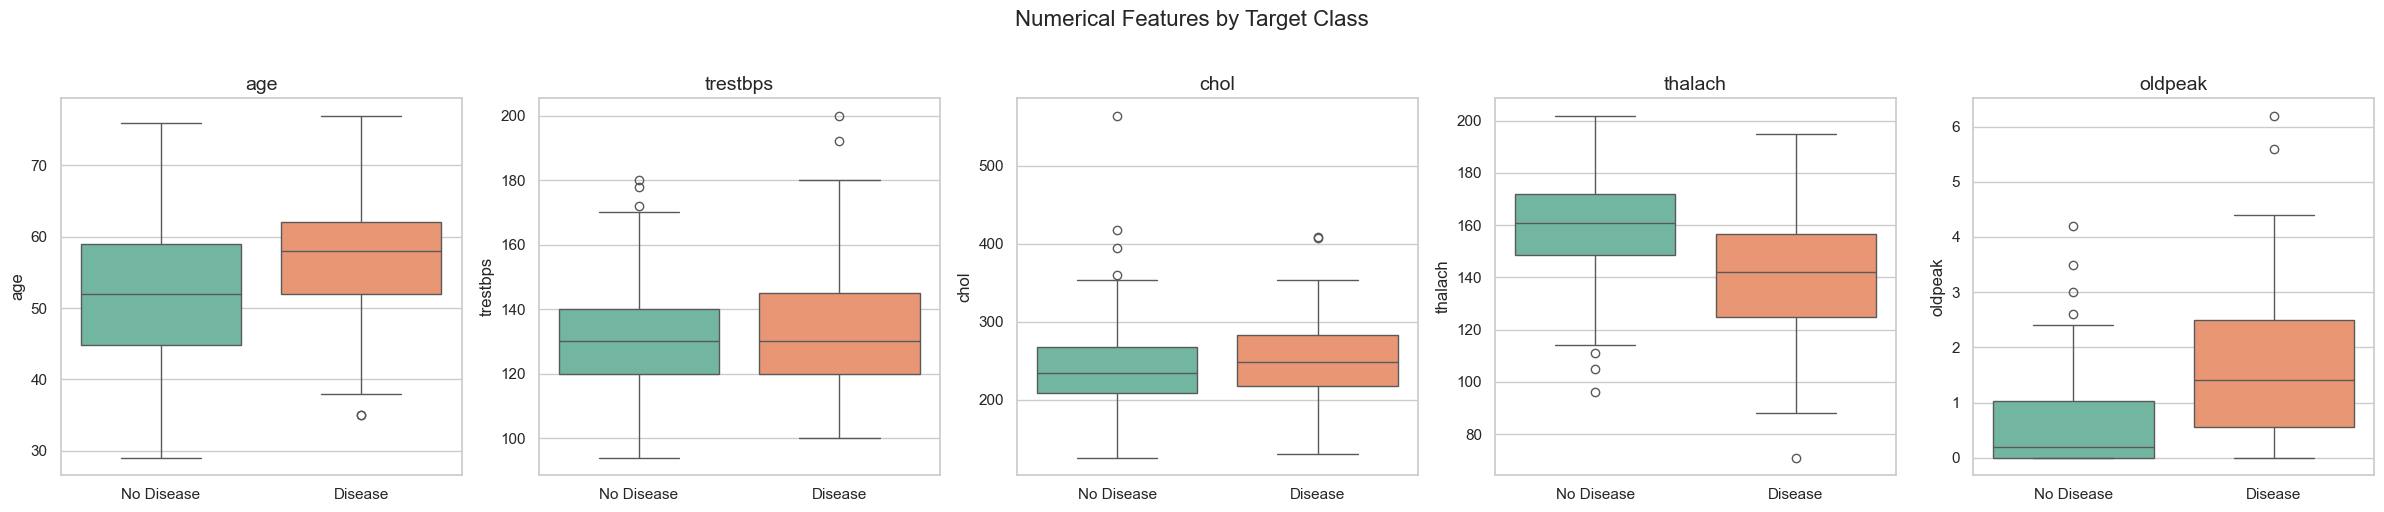

In [8]:
numerical_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
df_box = df.copy()
df_box['target'] = (df_box['num'] > 0).astype(int)

fig, axes = plt.subplots(1, 5, figsize=(24, 5))

for i, col in enumerate(numerical_features):
    sns.boxplot(data=df_box, x='target', y=col, ax=axes[i], palette=['#66c2a5', '#fc8d62'])
    axes[i].set_title(col, fontsize=14)
    axes[i].set_xticklabels(['No Disease', 'Disease'])
    axes[i].set_xlabel('')

fig.suptitle('Numerical Features by Target Class', fontsize=16, y=1.02)
fig.tight_layout()
fig.savefig(os.path.join(SAVE_DIR, 'boxplots_by_target.png'), dpi=150, bbox_inches='tight')
plt.show()

## 7. Categorical Feature Analysis

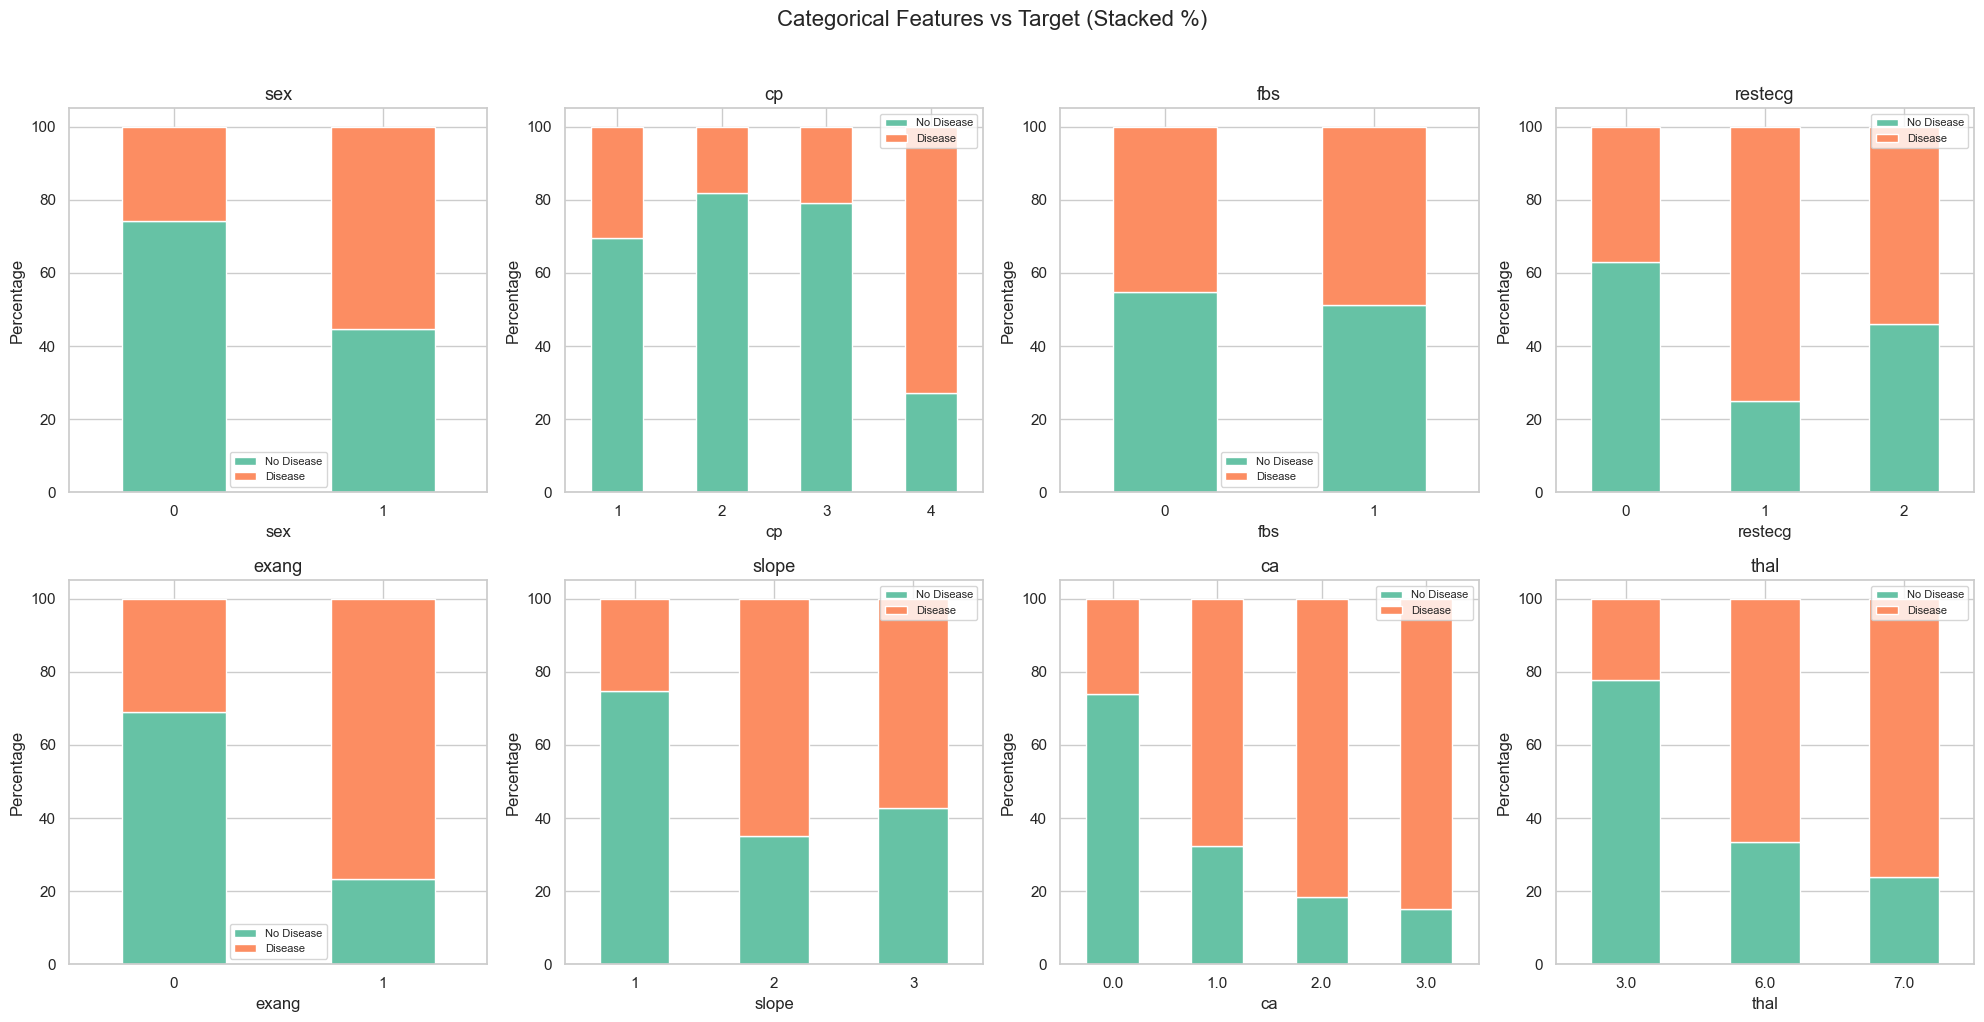

In [9]:
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
df_cat = df.copy()
df_cat['target'] = (df_cat['num'] > 0).astype(int)

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_features):
    ct = pd.crosstab(df_cat[col], df_cat['target'], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, ax=axes[i], color=['#66c2a5', '#fc8d62'])
    axes[i].set_title(col, fontsize=13)
    axes[i].set_ylabel('Percentage')
    axes[i].legend(['No Disease', 'Disease'], fontsize=8)
    axes[i].tick_params(axis='x', rotation=0)

fig.suptitle('Categorical Features vs Target (Stacked %)', fontsize=16, y=1.02)
fig.tight_layout()
fig.savefig(os.path.join(SAVE_DIR, 'categorical_vs_target.png'), dpi=150, bbox_inches='tight')
plt.show()

## 8. Pair Plot (Top Correlated Features)

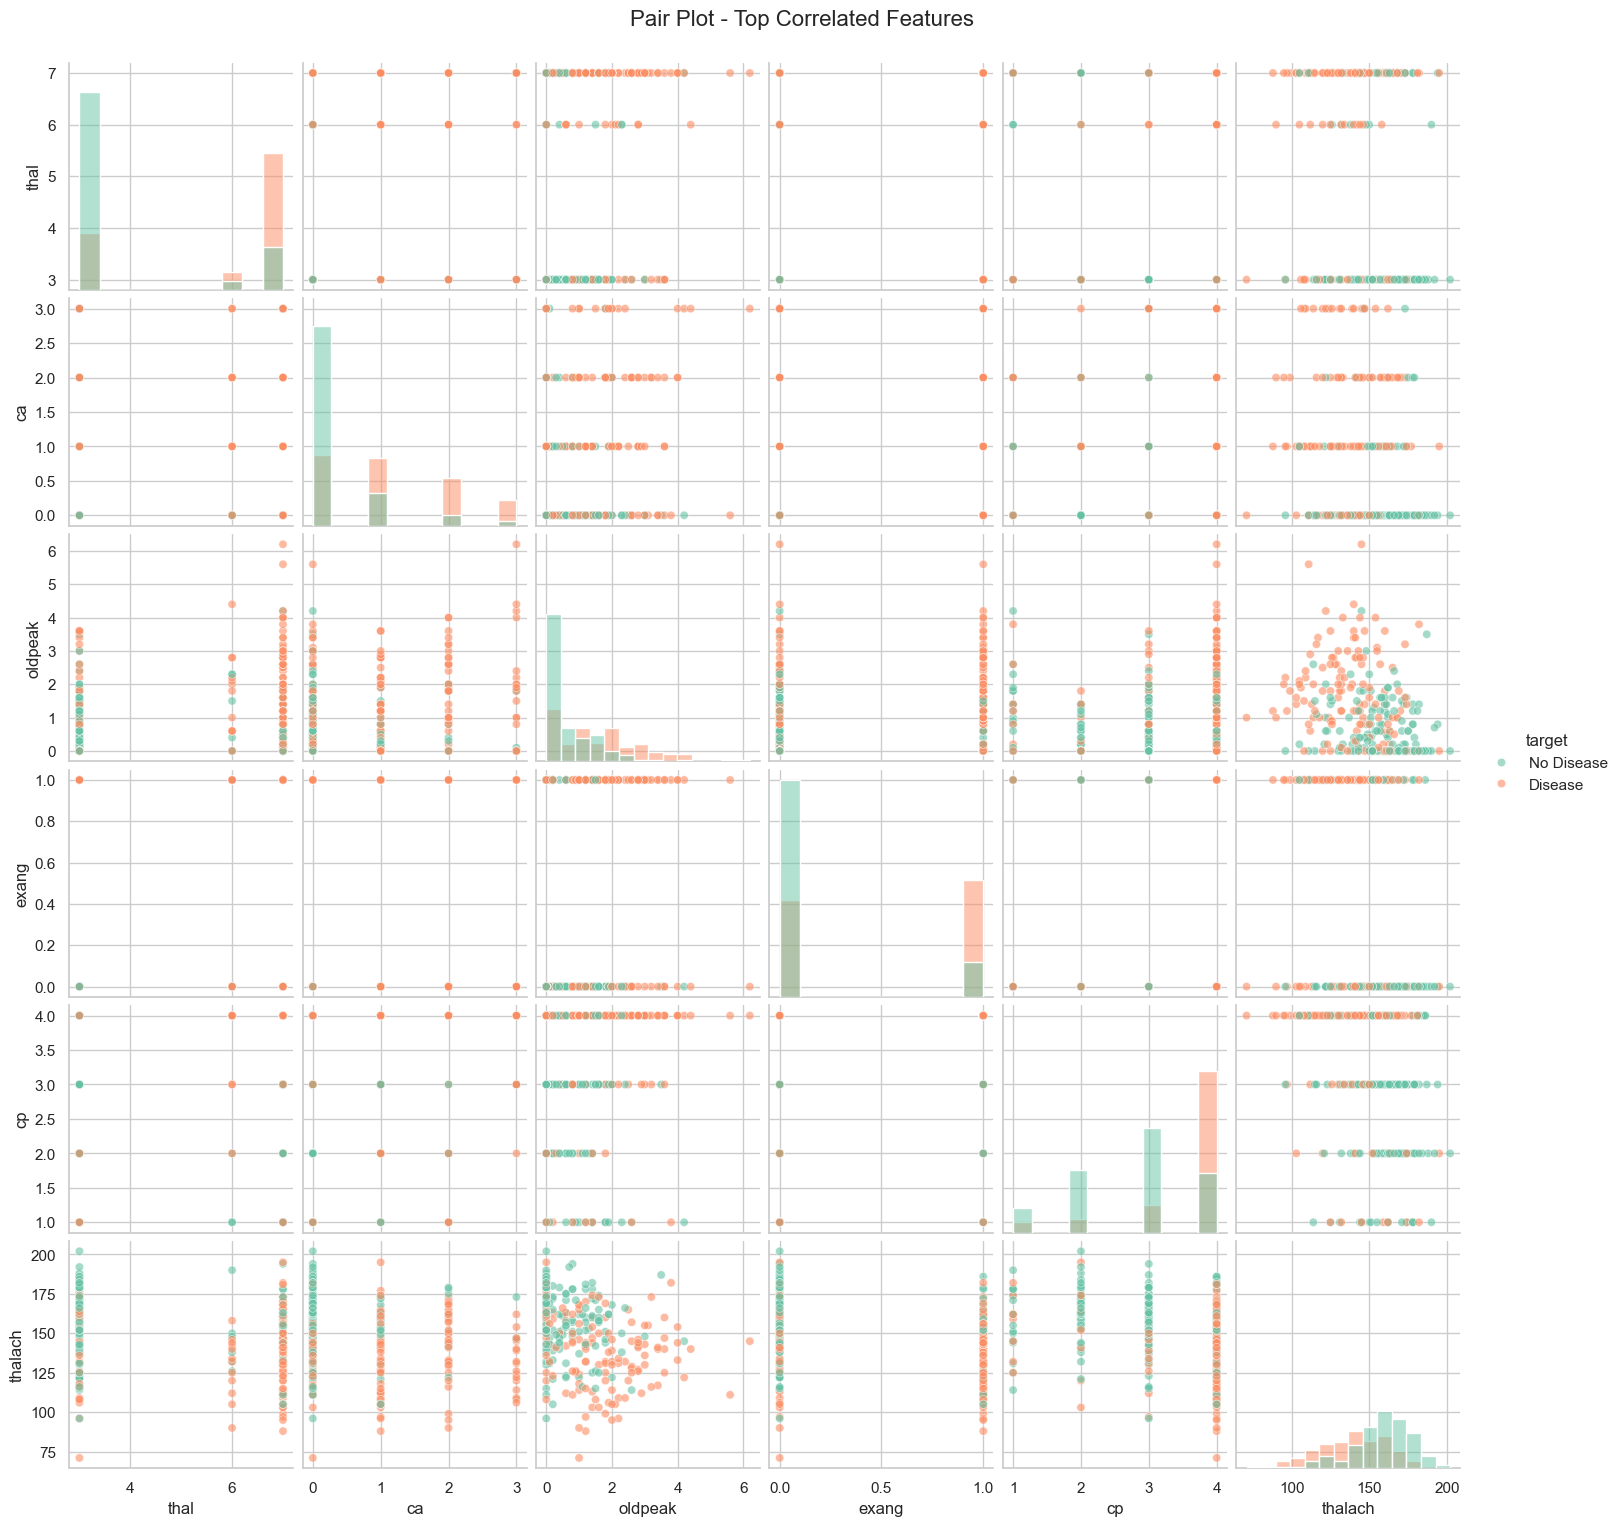

In [10]:
top_features = ['thal', 'ca', 'oldpeak', 'exang', 'cp', 'thalach']
df_pair = df.copy()
df_pair['target'] = (df_pair['num'] > 0).astype(int).map({0: 'No Disease', 1: 'Disease'})

g = sns.pairplot(df_pair[top_features + ['target']], hue='target',
                 palette={'No Disease': '#66c2a5', 'Disease': '#fc8d62'},
                 diag_kind='hist', plot_kws={'alpha': 0.6})
g.figure.suptitle('Pair Plot - Top Correlated Features', y=1.02, fontsize=16)
g.figure.savefig(os.path.join(SAVE_DIR, 'pairplot_top_features.png'), dpi=150, bbox_inches='tight')
plt.show()

## Summary

### Key Findings:
1. **Class balance**: Roughly balanced — 164 no disease (54%) vs 139 disease (46%)
2. **Missing values**: Only 6 total (ca: 4, thal: 2) — minimal, median imputation appropriate
3. **Strong predictors**: `thal`, `ca`, `oldpeak`, `exang`, `cp`, `thalach` show strongest correlation with target
4. **Age/cholesterol**: Less discriminative than expected — significant overlap between classes
5. **Chest pain type (cp)**: Asymptomatic (type 4) strongly associated with disease presence